/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5060/1321791161.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


                        text  cluster
0           bangli utc+08:00        4
1         buleleng utc+08:00        4
2         denpasar utc+08:00        4
3          gianyar utc+08:00        4
4         jembrana utc+08:00        4
5       karangasem utc+08:00        4
6        klungkung utc+08:00        4
7          tabanan utc+08:00        4
8           bangka utc+07:00        3
9     bangka barat utc+07:00        0
10  bangka selatan utc+07:00        3
11   bangka tengah utc+07:00        3
12        belitung utc+07:00        3
13  belitung timur utc+07:00        3
14  pangkal pinang utc+07:00        3
15         cilegon utc+07:00        3
16           lebak utc+07:00        3
17      pandeglang utc+07:00        3
18          serang utc+07:00        3
19          serang utc+07:00        3

Cluster counts:
cluster
0     23
1     15
2     55
3    285
4    135
Name: count, dtype: int64


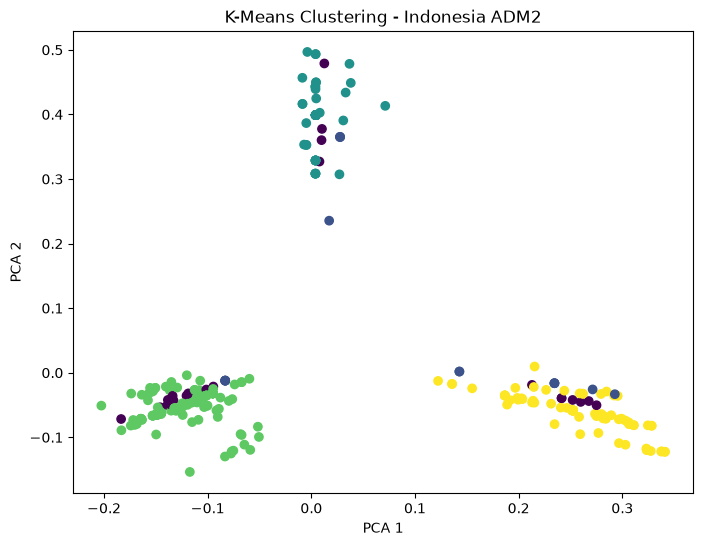


Saved: geo_subdivision_idn_adm2_kmeans.csv


In [1]:
# Install if needed:
# !pip install pandas scikit-learn matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("geo_subdivision_idn_adm2.csv")

# 2. Select text columns
text_cols = df.select_dtypes(include="object").columns

# 3. Combine text columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 4. NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["text"])

# 5. K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# 6. Show results
print(df[["text", "cluster"]].head(20))
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

# 7. Visualize
X_pca = PCA(n_components=2).fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering - Indonesia ADM2")
plt.show()

# 8. Save results
df.to_csv("geo_subdivision_idn_adm2_kmeans.csv", index=False)

print("\nSaved: geo_subdivision_idn_adm2_kmeans.csv")